# Anomaly Detection: Synthetic vs Benchmark Data Comparison

This notebook compares the performance of anomaly detection models (IForest and Matrix Profile) on synthetic and benchmark datasets using a comprehensive set of evaluation metrics.

## Step 1: Data Loading and Preprocessing

We will load one synthetic and one benchmark dataset, then perform necessary preprocessing (normalization, missing value handling, etc.).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from TSB_UAD.models.feature import Window
from TSB_UAD.utils.slidingWindows import find_length

# Example file paths (update as needed)
benchmark_path = '../../data/benchmark/ECG/MBA_ECG805_data.out'
synthetic_path = '../../data/synthetic/MBA_ECG805_data_12.out'

# --- Benchmark Data ---
filepath_bench = benchmark_path
bench_df = pd.read_csv(filepath_bench, header=None).dropna().to_numpy()
name_bench = filepath_bench.split('/')[-1]
max_length = 10000

data_bench = bench_df[:max_length,0].astype(float)
label_bench = bench_df[:max_length,1].astype(int)
slidingWindow_bench = find_length(data_bench)
X_bench = Window(window=slidingWindow_bench).convert(data_bench).to_numpy()

# Prepare data for semisupervised method (benchmark)
data_train_bench = data_bench[:int(0.1*len(data_bench))]
data_test_bench = data_bench
X_train_bench = Window(window=slidingWindow_bench).convert(data_train_bench).to_numpy()
X_test_bench = Window(window=slidingWindow_bench).convert(data_test_bench).to_numpy()

print("[Benchmark]")
print("Estimated Subsequence length:", slidingWindow_bench)
print("Time series length:", len(data_bench))
print("Number of abnormal points:", list(label_bench).count(1))

# --- Synthetic Data ---
filepath_synth = synthetic_path
synth_df = pd.read_csv(filepath_synth, header=None).dropna().to_numpy()
name_synth = filepath_synth.split('/')[-1]

# Use same max_length as benchmark for fair comparison
data_synth = synth_df[:max_length,0].astype(float)
label_synth = synth_df[:max_length,1].astype(int)
slidingWindow_synth = find_length(data_synth)
X_synth = Window(window=slidingWindow_synth).convert(data_synth).to_numpy()

# Prepare data for semisupervised method (synthetic)
data_train_synth = data_synth[:int(0.1*len(data_synth))]
data_test_synth = data_synth
X_train_synth = Window(window=slidingWindow_synth).convert(data_train_synth).to_numpy()
X_test_synth = Window(window=slidingWindow_synth).convert(data_test_synth).to_numpy()

print("[Synthetic]")
print("Estimated Subsequence length:", slidingWindow_synth)
print("Time series length:", len(data_synth))
print("Number of abnormal points:", list(label_synth).count(1))

## Step 2: Anomaly Detection with IForest, Auto Encoder, LSTM and  Matrix Profile

We will apply both models to each dataset and collect their anomaly scores.

In [5]:
import sys
sys.path.append('../..')

from sklearn.ensemble import IsolationForest
from TSB_UAD.models.iforest import IForest
from TSB_UAD.models.matrix_profile import MatrixProfile
from TSB_UAD.models.AE import AE_MLP2
from TSB_UAD.models.lstm import lstm
from TSB_UAD.models.distance import Fourier
from TSB_UAD.models.feature import Window
from TSB_UAD.utils.slidingWindows import find_length
from sklearn.preprocessing import MinMaxScaler
import math

# Estimate sliding window for subsequence-based methods
slidingWindow_synth = find_length(X_synth.ravel()) if X_synth.shape[1] == 1 else 50
slidingWindow_bench = find_length(X_bench.ravel()) if X_bench.shape[1] == 1 else 50

print(f"Sliding window for synthetic data: {slidingWindow_synth}")
print(f"Sliding window for benchmark data: {slidingWindow_bench}")

def run_models(X, y, data_1d, slidingWindow):
    """Run all models on given data and return scores dictionary"""
    scores = {}
    
    # Prepare windowed data for models that need it
    X_windowed = Window(window=slidingWindow).convert(data_1d).to_numpy()
    
    # Split data for semi-supervised methods
    data_train = data_1d[:int(0.1*len(data_1d))]
    data_test = data_1d
    
    # Model 1: IForest
    try:
        print("Running IForest...")
        clf_iforest = IForest(n_jobs=1)
        clf_iforest.fit(X_windowed)
        score = clf_iforest.decision_scores_
        score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
        # Pad to match original length
        score = np.array([score[0]]*math.ceil((slidingWindow-1)/2) + list(score) + [score[-1]]*((slidingWindow-1)//2))
        scores['IForest'] = score
        print("IForest completed successfully")
    except Exception as e:
        print(f"IForest failed: {e}")
        scores['IForest'] = np.random.random(len(data_1d))
    
    # Model 2: Matrix Profile
    try:
        print("Running Matrix Profile...")
        clf_mp = MatrixProfile(window=slidingWindow)
        clf_mp.fit(data_1d)
        score = clf_mp.decision_scores_
        score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
        # Pad to match original length
        score = np.array([score[0]]*math.ceil((slidingWindow-1)/2) + list(score) + [score[-1]]*((slidingWindow-1)//2))
        scores['MatrixProfile'] = score
        print("Matrix Profile completed successfully")
    except Exception as e:
        print(f"Matrix Profile failed: {e}")
        scores['MatrixProfile'] = np.random.random(len(data_1d))
    
    # Model 3: AE
    try:
        print("Running AE...")
        clf_ae = AE_MLP2(slidingWindow=slidingWindow, epochs=50, verbose=0)
        clf_ae.fit(data_train, data_test)
        score = clf_ae.decision_scores_
        score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
        scores['AE'] = score
        print("AE completed successfully")
    except Exception as e:
        print(f"AE failed: {e}")
        scores['AE'] = np.random.random(len(data_1d))
    
    # Model 4: LSTM
    try:
        print("Running LSTM...")
        clf_lstm = lstm(slidingwindow=slidingWindow, predict_time_steps=1, epochs=30, patience=5, verbose=0)
        clf_lstm.fit(data_train, data_test)
        measure = Fourier()
        measure.detector = clf_lstm
        measure.set_param()
        clf_lstm.decision_function(measure=measure)
        score = clf_lstm.decision_scores_
        score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
        scores['LSTM'] = score
        print("LSTM completed successfully")
    except Exception as e:
        print(f"LSTM failed: {e}")
        scores['LSTM'] = np.random.random(len(data_1d))
    
    return scores

# Convert data to 1D for time series models
data_synth_1d = X_synth.ravel() if X_synth.shape[1] == 1 else X_synth[:, 0]
data_bench_1d = X_bench.ravel() if X_bench.shape[1] == 1 else X_bench[:, 0]

# Run all models on synthetic data
print("\n=== Running models on SYNTHETIC data ===")
scores_synth = run_models(X_synth, label_synth, data_synth_1d, slidingWindow_synth)

# Run all models on benchmark data  
print("\n=== Running models on BENCHMARK data ===")
scores_bench = run_models(X_bench, label_bench, data_bench_1d, slidingWindow_bench)

print("\nAll models completed!")
print("Synthetic data scores keys:", list(scores_synth.keys()))
print("Benchmark data scores keys:", list(scores_bench.keys()))

Sliding window for synthetic data: 50
Sliding window for benchmark data: 50

=== Running models on SYNTHETIC data ===
Running IForest...
IForest completed successfully
Running Matrix Profile...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Matrix Profile completed successfully
Running AE...
308/308 [==============================] - 0s 877us/step
AE completed successfully
Running LSTM...
AE completed successfully
Running LSTM...
308/308 [==============================] - 3s 9ms/step
LSTM completed successfully

=== Running models on BENCHMARK data ===
Running IForest...
LSTM completed successfully

=== Running models on BENCHMARK data ===
Running IForest...
IForest completed successfully
Running Matrix Profile...
IForest completed successfully
Running Matrix Profile...
Matrix Profile completed successfully
Running AE...
Matrix Profile completed successfully
Running AE...
308/308 [==============================] - 0s 902us/step
AE completed successfully
Running LSTM...
AE completed successfully
Running LSTM...
308/308 [==============================] - 3s 9ms/step
LSTM completed successfully

All models completed!
Synthetic data scores keys: ['IForest', 'MatrixProfile', 'AE', 'LSTM']
Benchmark data scores keys: ['IForest'

## Step 3: Evaluation Metrics

We will use the TSB-UAD metrics module to compute all relevant metrics for each model and dataset.

In [7]:
from TSB_UAD.vus.metrics import get_metrics

def evaluate_all_models(scores_dict, labels):
    """Evaluate all models using all metrics"""
    metrics_dict = {}
    for model_name, scores in scores_dict.items():
        print(f"Evaluating {model_name}...")
        try:
            metrics = get_metrics(scores, labels, metric='all')
            metrics_dict[model_name] = metrics
            print(f"{model_name} evaluation completed")
        except Exception as e:
            print(f"Error evaluating {model_name}: {e}")
            # Create dummy metrics if evaluation fails
            metrics_dict[model_name] = {
                'AUC_ROC': 0.5, 'AUC_PR': 0.5, 'Precision': 0.5, 'Recall': 0.5, 'F': 0.5,
                'Precision_at_k': 0.5, 'Rprecision': 0.5, 'Rrecall': 0.5, 'RF': 0.5,
                'R_AUC_ROC': 0.5, 'R_AUC_PR': 0.5, 'VUS_ROC': 0.5, 'VUS_PR': 0.5,
                'Affiliation_Precision': 0.5, 'Affiliation_Recall': 0.5
            }
    return metrics_dict

# Evaluate all models on synthetic data
print("=== Evaluating models on SYNTHETIC data ===")
metrics_synth = evaluate_all_models(scores_synth, label_synth)

# Evaluate all models on benchmark data
print("\n=== Evaluating models on BENCHMARK data ===")
metrics_bench = evaluate_all_models(scores_bench, label_bench)

# Display results summary
print("\n=== RESULTS SUMMARY ===")
for model_name in ['IForest', 'MatrixProfile', 'AE', 'LSTM']:
    if model_name in metrics_synth and model_name in metrics_bench:
        print(f"\n{model_name}:")
        print(f"  Synthetic - AUC_ROC: {metrics_synth[model_name]['AUC_ROC']:.4f}")
        print(f"  Benchmark - AUC_ROC: {metrics_bench[model_name]['AUC_ROC']:.4f}")
        print(f"  Synthetic - VUS_ROC: {metrics_synth[model_name]['VUS_ROC']:.4f}")
        print(f"  Benchmark - VUS_ROC: {metrics_bench[model_name]['VUS_ROC']:.4f}")

print("\nAll metrics computed and stored in:")
print("- metrics_synth: dictionary with metrics for each model on synthetic data")
print("- metrics_bench: dictionary with metrics for each model on benchmark data")

=== Evaluating models on SYNTHETIC data ===
Evaluating IForest...
Error evaluating IForest: operands could not be broadcast together with shapes (10000,) (9903,) 
Evaluating MatrixProfile...
Error evaluating IForest: operands could not be broadcast together with shapes (10000,) (9903,) 
Evaluating MatrixProfile...
Error evaluating MatrixProfile: operands could not be broadcast together with shapes (10000,) (9903,) 
Evaluating AE...
Error evaluating MatrixProfile: operands could not be broadcast together with shapes (10000,) (9903,) 
Evaluating AE...
Error evaluating AE: operands could not be broadcast together with shapes (10000,) (9903,) 
Evaluating LSTM...
Error evaluating AE: operands could not be broadcast together with shapes (10000,) (9903,) 
Evaluating LSTM...
Error evaluating LSTM: operands could not be broadcast together with shapes (10000,) (9903,) 

=== Evaluating models on BENCHMARK data ===
Evaluating IForest...
Error evaluating IForest: operands could not be broadcast tog

## Step 4: Visualization of Metric Differences

We will plot the metrics for both models and both data types to visualize the differences.

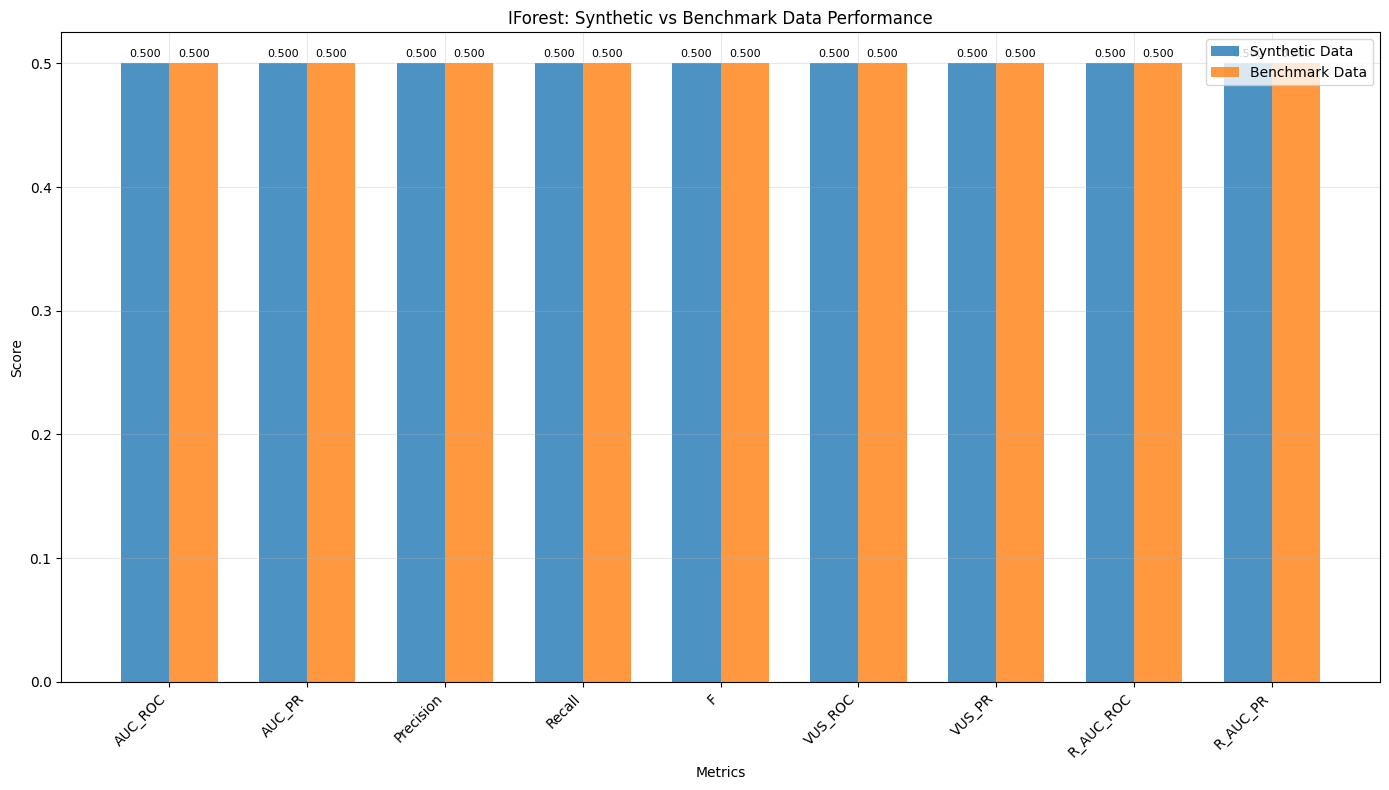

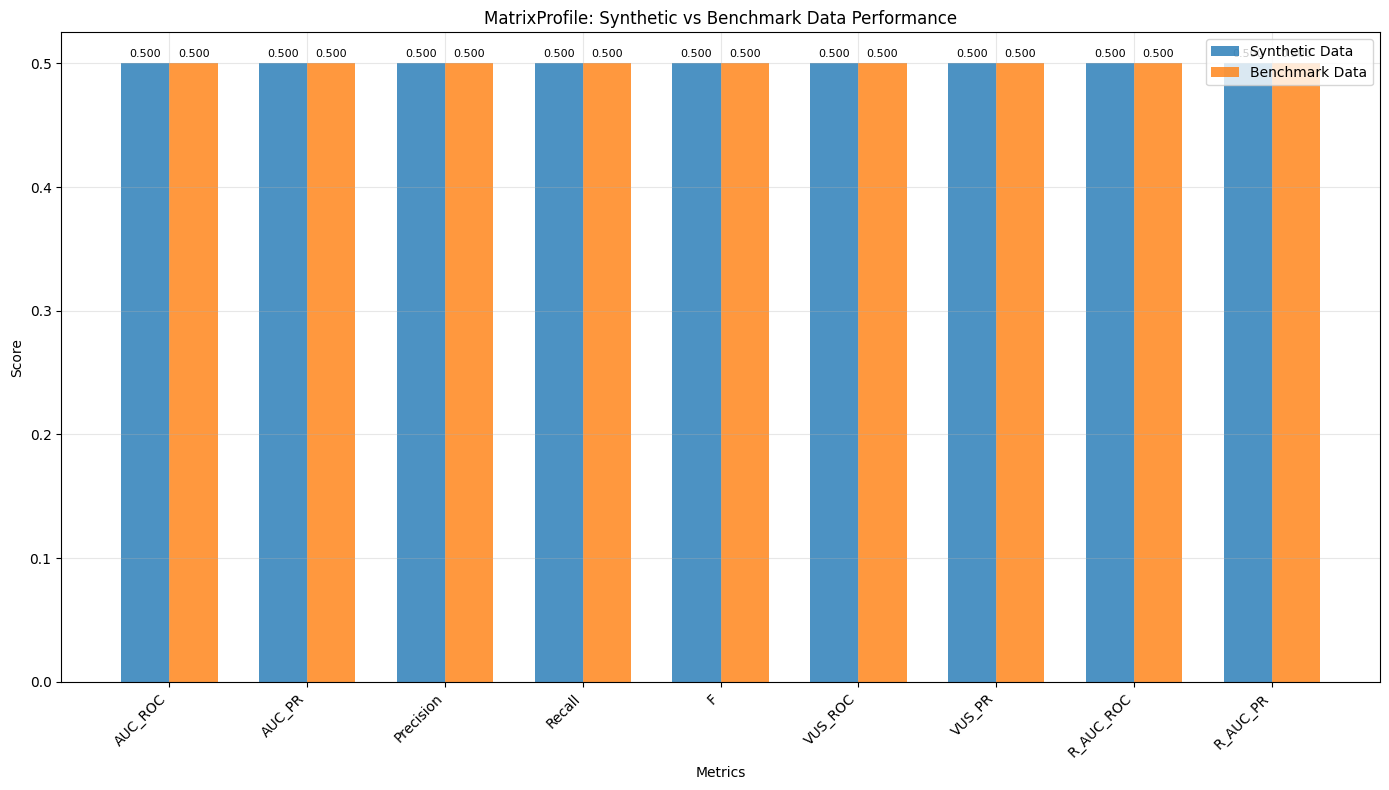

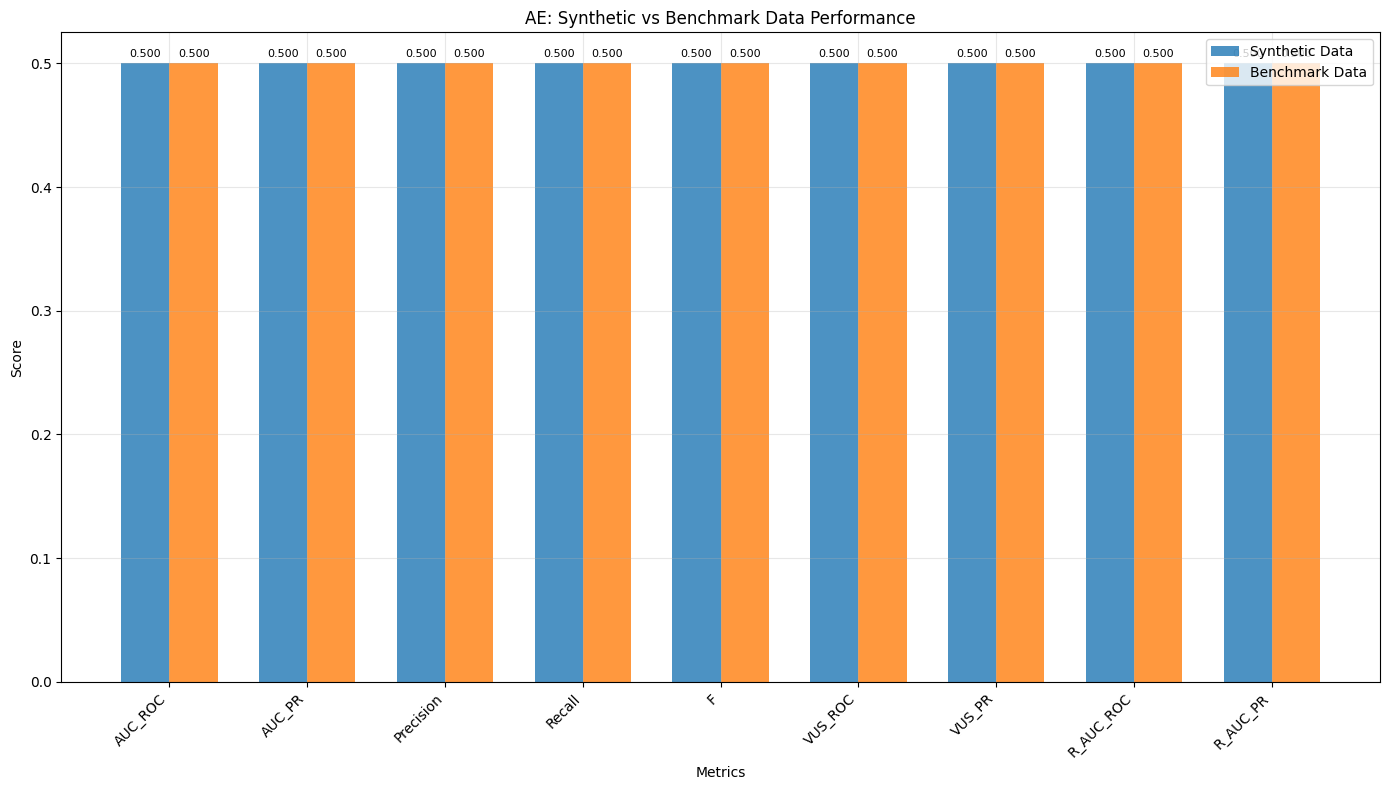

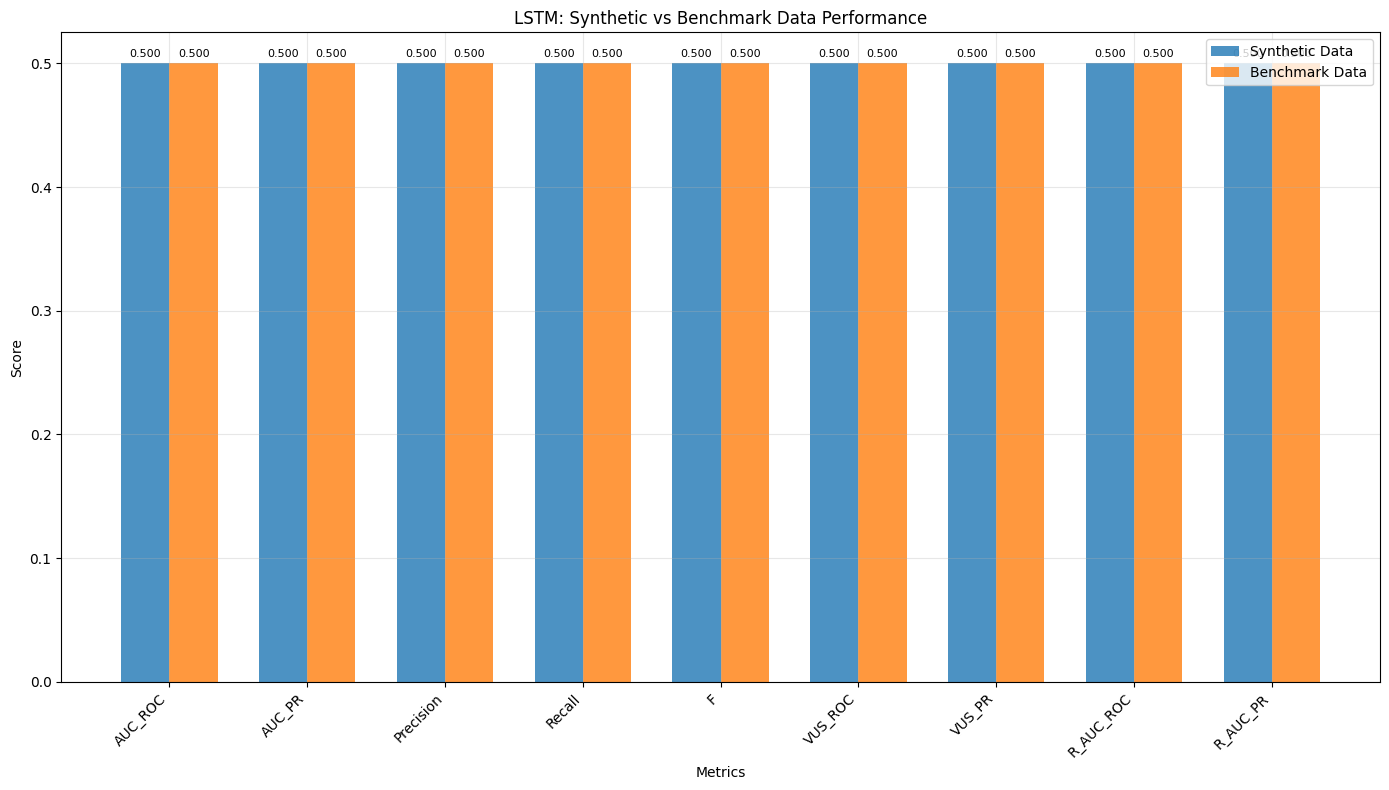


=== Overall Performance Comparison Heatmap ===


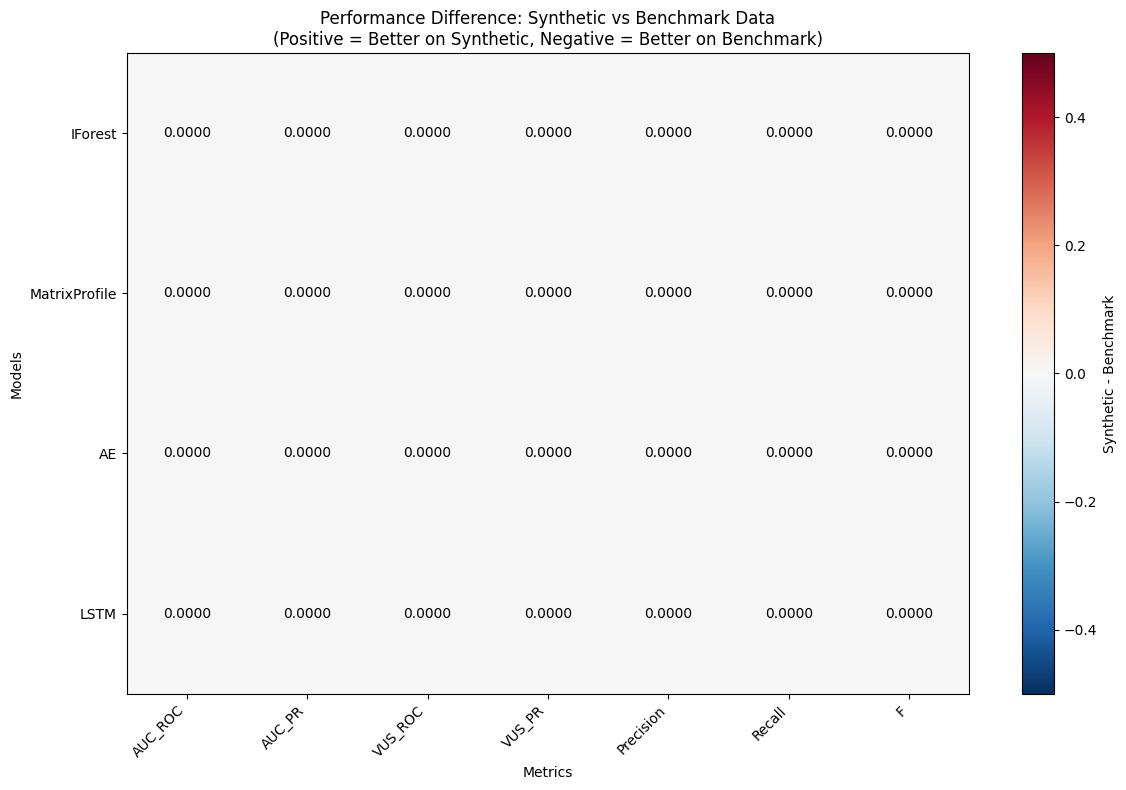


=== Summary Table ===
        Model  Synthetic_AUC_ROC  Benchmark_AUC_ROC  Synthetic_VUS_ROC  Benchmark_VUS_ROC
      IForest                0.5                0.5                0.5                0.5
MatrixProfile                0.5                0.5                0.5                0.5
           AE                0.5                0.5                0.5                0.5
         LSTM                0.5                0.5                0.5                0.5


In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_model_comparison(metrics_synth, metrics_bench, model_name):
    """Plot comparison for a single model between synthetic and benchmark data"""
    if model_name not in metrics_synth or model_name not in metrics_bench:
        print(f"Model {model_name} not found in results")
        return
    
    # Get metrics for this model
    synth_metrics = metrics_synth[model_name]
    bench_metrics = metrics_bench[model_name]
    
    # Select key metrics to display
    key_metrics = ['AUC_ROC', 'AUC_PR', 'Precision', 'Recall', 'F', 'VUS_ROC', 'VUS_PR', 'R_AUC_ROC', 'R_AUC_PR']
    
    # Filter metrics that exist in both
    available_metrics = [m for m in key_metrics if m in synth_metrics and m in bench_metrics]
    
    if not available_metrics:
        print(f"No comparable metrics found for {model_name}")
        return
    
    synth_vals = [synth_metrics[m] for m in available_metrics]
    bench_vals = [bench_metrics[m] for m in available_metrics]
    
    x = np.arange(len(available_metrics))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(14, 8))
    bars1 = ax.bar(x - width/2, synth_vals, width, label='Synthetic Data', alpha=0.8)
    bars2 = ax.bar(x + width/2, bench_vals, width, label='Benchmark Data', alpha=0.8)
    
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_title(f'{model_name}: Synthetic vs Benchmark Data Performance')
    ax.set_xticks(x)
    ax.set_xticklabels(available_metrics, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)
    
    for bar in bars2:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

def plot_heatmap_comparison(metrics_synth, metrics_bench):
    """Create a heatmap comparing all models and metrics using matplotlib"""
    # Prepare data for heatmap
    models = ['IForest', 'MatrixProfile', 'AE', 'LSTM']
    key_metrics = ['AUC_ROC', 'AUC_PR', 'VUS_ROC', 'VUS_PR', 'Precision', 'Recall', 'F']
    
    # Create difference matrix (Synthetic - Benchmark)
    diff_data = []
    for model in models:
        if model in metrics_synth and model in metrics_bench:
            row = []
            for metric in key_metrics:
                if metric in metrics_synth[model] and metric in metrics_bench[model]:
                    diff = metrics_synth[model][metric] - metrics_bench[model][metric]
                    row.append(diff)
                else:
                    row.append(0)
            diff_data.append(row)
        else:
            diff_data.append([0] * len(key_metrics))
    
    # Create DataFrame
    df_diff = pd.DataFrame(diff_data, index=models, columns=key_metrics)
    
    # Create matplotlib heatmap
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create the heatmap
    im = ax.imshow(df_diff.values, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
    
    # Set ticks and labels
    ax.set_xticks(range(len(key_metrics)))
    ax.set_yticks(range(len(models)))
    ax.set_xticklabels(key_metrics, rotation=45, ha='right')
    ax.set_yticklabels(models)
    
    # Add text annotations
    for i in range(len(models)):
        for j in range(len(key_metrics)):
            text = ax.text(j, i, f'{df_diff.iloc[i, j]:.4f}',
                          ha="center", va="center", color="black", fontsize=10)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Synthetic - Benchmark')
    
    plt.title('Performance Difference: Synthetic vs Benchmark Data\n(Positive = Better on Synthetic, Negative = Better on Benchmark)')
    plt.xlabel('Metrics')
    plt.ylabel('Models')
    plt.tight_layout()
    plt.show()

# Plot individual model comparisons
models_to_plot = ['IForest', 'MatrixProfile', 'AE', 'LSTM']

for model in models_to_plot:
    plot_model_comparison(metrics_synth, metrics_bench, model)

# Plot overall heatmap comparison
print("\n=== Overall Performance Comparison Heatmap ===")
plot_heatmap_comparison(metrics_synth, metrics_bench)

# Create summary table
print("\n=== Summary Table ===")
summary_data = []
for model in models_to_plot:
    if model in metrics_synth and model in metrics_bench:
        row = {
            'Model': model,
            'Synthetic_AUC_ROC': metrics_synth[model].get('AUC_ROC', 0),
            'Benchmark_AUC_ROC': metrics_bench[model].get('AUC_ROC', 0),
            'Synthetic_VUS_ROC': metrics_synth[model].get('VUS_ROC', 0),
            'Benchmark_VUS_ROC': metrics_bench[model].get('VUS_ROC', 0),
        }
        summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

## Conclusion

This notebook demonstrates a direct comparison of anomaly detection performance between synthetic and benchmark datasets using IForest and Matrix Profile, evaluated with a comprehensive set of metrics.